Solve the Laplace equation $u_{xx} + u_{yy} = 0$ for a square mesh with boundary condition,

$0 \le x \le 1 \quad ; 0 \le y \le 1$

$\Delta x = \Delta y = h = 1/3 = 0.333$

$u(x, 0) = 360 x \quad ; u(x, 1) = 240(1-x)$

$u(0, y) = 240 y \quad ; u(1, y) = 360(1-y)$

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

Creating square mesh with boundry condition

Setting input

iter=21 maxd=2.96e-10


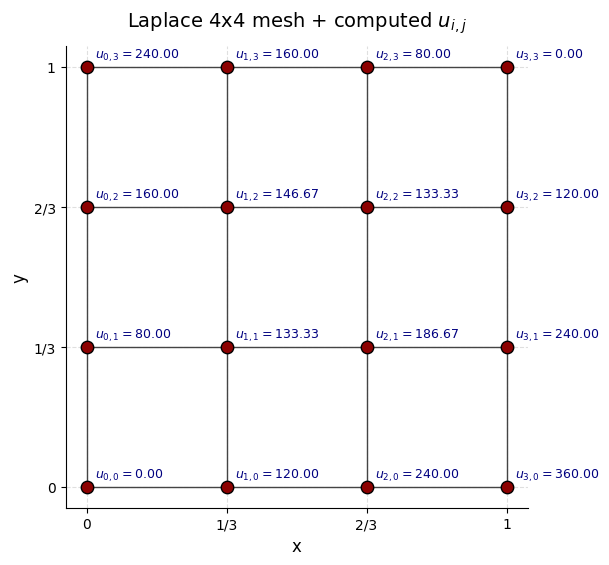

u array (j rows, i cols):
 [[  0.         120.         240.         360.        ]
 [ 80.         133.33333333 186.66666667 240.        ]
 [160.         146.66666667 133.33333333 120.        ]
 [240.         160.          80.           0.        ]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# mesh
x = np.linspace(0, 1, 4)    # 4 nodes, h=1/3
y = np.linspace(0, 1, 4)
X, Y = np.meshgrid(x, y)

# boundary data
u = np.zeros((4, 4), float)
u[0, :] = 360*x          # bottom y=0  (row j=0)
u[-1, :] = 240*(1-x)     # top y=1 (row j=3)
u[:, 0] = 240*y          # left x=0  (col i=0)
u[:, -1] = 360*(1-y)     # right x=1 (col i=3)

# No interior solve yet: only boundary values
print("Boundary values for u on the square domain:")
print("bottom y=0 :", u[0, :])
print("top    y=1 :", u[-1, :])
print("left   x=0 :", u[:, 0])
print("right  x=1 :", u[:, -1])

# annotate, plot
plt.figure(figsize=(6,6))
for xi in x:
    plt.plot([xi]*len(y), y, color='#444444', lw=1)
for yi in y:
    plt.plot(x, [yi]*len(x), color='#444444', lw=1)
plt.scatter(X, Y, c='darkred', s=80, edgecolor='k', zorder=5)

for j in range(4):
    for i in range(4):
        plt.text(X[j,i]+0.02, Y[j,i]+0.02,
                 f'$u_{{{i},{j}}}={u[j,i]:.2f}$',
                 color='navy', fontsize=9, weight='bold')

plt.title('Laplace 4x4 mesh + computed $u_{i,j}$', fontsize=14, pad=14)
plt.xlabel('x', fontsize=12); plt.ylabel('y', fontsize=12)
plt.axis('square')
plt.xlim(-0.05, 1.05); plt.ylim(-0.05, 1.05)
plt.xticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
plt.yticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
for k in ['top','right']:
    plt.gca().spines[k].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("u array (j rows, i cols):\n", u)